# Game-Start Free Building Levels

Reads `free_building_levels` weights from `graphs/building_capacity/data/free_building_levels_sheet.csv`, enriches the generated static location parquet with game-start parser data, and computes where free building capacity would be available.


In [12]:
%matplotlib inline

from pathlib import Path
import os

import matplotlib.pyplot as plt
import polars as pl
from IPython.display import Markdown, display

from prosper_or_perish_constructor.free_building_levels import (
    DEFAULT_DISPLAY_DECIMALS,
    LOCAL_BUILD_BUILDINGS_EFFICIENCY_COLUMN,
    LOCAL_CONSTRUCTION_SPEED_COLUMN,
    build_location_map_frame,
    compute_free_building_levels,
    compute_local_build_buildings_efficiency,
    compute_local_construction_speed,
    contribution_category_summary,
    contribution_factor_group_summary,
    contribution_value_summary,
    explain_development_components,
    load_free_building_level_weights,
    load_game_start_development_weights,
    load_free_building_level_location_frame,
    local_free_building_levels_sheet_csv_path,
    round_numeric_columns,
    summarize_free_building_levels,
    validate_sheet_values_against_game_sources,
)

pl.Config.set_float_precision(DEFAULT_DISPLAY_DECIMALS)
pl.Config.set_tbl_rows(80)
pl.Config.set_tbl_cols(30)


def find_repo(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "constructor.toml").is_file():
            return candidate
    raise FileNotFoundError("Could not find constructor.toml above current working directory")


REPO = find_repo(Path.cwd().resolve())
PROJECT = REPO / "constructor.toml"
print(f"repo={REPO}")
print(f"project={PROJECT}")


def color_limits(values: pl.Series) -> tuple[float, float]:
    vmin = float(values.min())
    vmax = float(values.max())
    if vmin == vmax:
        spread = max(abs(vmin) * 0.05, 0.5)
        vmin -= spread
        vmax += spread
    return vmin, vmax


def plot_location_world_map(
    frame: pl.DataFrame,
    value_column: str,
    *,
    title: str,
    cmap: str = "viridis",
    point_size: float = 3,
) -> None:
    plt.close("all")
    plot_data = frame.select("approx_lon", "approx_lat", value_column).to_dict(as_series=False)
    vmin, vmax = color_limits(frame[value_column])
    fig, ax = plt.subplots(figsize=(16, 8), dpi=140)
    scatter = ax.scatter(
        plot_data["approx_lon"],
        plot_data["approx_lat"],
        c=plot_data[value_column],
        s=point_size,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        linewidths=0,
        alpha=0.85,
    )
    ax.set_xlim(-180, 180)
    ax.set_ylim(-65, 85)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(title)
    fig.colorbar(scatter, ax=ax, label=value_column)
    ax.grid(alpha=0.15)
    plt.show()


repo=/home/jan/development/ProsperOrPerishConstructor
project=/home/jan/development/ProsperOrPerishConstructor/constructor.toml


## Source Weights

`graphs/building_capacity/data/free_building_levels_sheet.csv` is the source of truth. It uses one tidy row per factor/value pair with columns:

- `section` (`fixed` or `dynamic`)
- `factor`, `value`, `free_building_levels`
- `local_build_buildings_efficiency` and `local_construction_speed` for `topography`, `vegetation`, `river_level` (1-5 only), `is_port`, and `location_rank`
- `river_level` 0 means no river and has no weight row (baseline), matching in-game `has_river` triggers

Edit the CSV, then re-run the cell below to reload the Polars weights frame.


In [13]:
sheet_csv = local_free_building_levels_sheet_csv_path(REPO)
weights = load_free_building_level_weights(REPO)

print(f"source_csv={sheet_csv}")
print(f"weight_rows={weights.height}")
display(round_numeric_columns(weights.sort(["factor", "value"])))
display(Markdown(
    f"`{LOCAL_BUILD_BUILDINGS_EFFICIENCY_COLUMN}` is currently filled for "
    f"{weights.filter(pl.col(LOCAL_BUILD_BUILDINGS_EFFICIENCY_COLUMN).is_not_null()).height} rows; "
    f"`{LOCAL_CONSTRUCTION_SPEED_COLUMN}` matches on "
    f"{weights.filter(pl.col(LOCAL_CONSTRUCTION_SPEED_COLUMN).is_not_null()).height} rows."
    " rows."
))


source_csv=/home/jan/development/ProsperOrPerishConstructor/graphs/building_capacity/data/free_building_levels_sheet.csv
weight_rows=35


section,factor,value,free_building_levels,local_build_buildings_efficiency,local_construction_speed
str,str,str,f64,f64,f64
"""dynamic""","""capital""","""true""",25.00,null,null
"""dynamic""","""development""","""per_point""",0.50,null,null
"""fixed""","""is_port""","""true""",15.00,0.15,0.15
"""dynamic""","""local_governor""","""true""",15.00,null,null
"""dynamic""","""location_rank""","""city""",50.00,-0.30,-0.30
"""dynamic""","""location_rank""","""megalopolis""",70.00,-0.30,-0.30
"""dynamic""","""location_rank""","""rural_settlement""",30.00,-0.30,-0.30
"""dynamic""","""location_rank""","""town""",40.00,-0.30,-0.30
"""dynamic""","""market_center""","""true""",15.00,null,null


`local_build_buildings_efficiency` is currently filled for 21 rows; `local_construction_speed` matches on 21 rows. rows.

## Location Frame

This loads the existing generated location parquet, applies current location-template overlays, then enriches it with game-start ranks, market centers, capitals, roads, ports, real river levels from `rivers.png`, and computed game-start development.


In [14]:
locations = load_free_building_level_location_frame(REPO, PROJECT)

coverage = locations.select(
    pl.len().alias("locations"),
    pl.col("has_river").sum().alias("has_river"),
    (pl.col("river_level") > 0).sum().alias("river_level_nonzero"),
    pl.col("market_center").sum().alias("market_centers"),
    pl.col("capital").sum().alias("capitals"),
    pl.col("is_port").sum().alias("ports"),
    (pl.col("road_level") > 0).sum().alias("road_locations"),
)
display(coverage)

display(
    round_numeric_columns(
        locations.select(
            "location_id",
            "location_tag",
            "province",
            "region",
            "topography",
            "vegetation",
            "river_level",
            "location_rank",
            "road_level",
            "development",
            "effective_development",
            "market_center",
            "capital",
            "province_capital",
            "is_port",
        ).head(20)
    )
)


source_validation = validate_sheet_values_against_game_sources(
    weights,
    locations,
    repo=REPO,
    project=PROJECT,
)

display(Markdown("### Sheet Value Source Validation"))
display(source_validation)


locations,has_river,river_level_nonzero,market_centers,capitals,ports,road_locations
u32,u32,u32,u32,u32,u32,u32
20929,10511,10511,121,1911,4418,1613


location_id,location_tag,province,region,topography,vegetation,river_level,location_rank,road_level,development,effective_development,market_center,capital,province_capital,is_port
i64,str,str,str,str,str,i64,str,i32,f64,f64,bool,bool,bool,bool
20391,"""jagua""","""havana_province""","""caribbean_region""","""flatland""","""grasslands""",0,"""rural_settlement""",0,-3.00,0.00,false,false,false,true
2067,"""montreuillon""","""nevernais_province""","""france_region""","""flatland""","""woods""",0,"""rural_settlement""",0,19.00,19.00,false,false,false,false
21166,"""chestowee""","""tanasi_province""","""east_coast_region""","""flatland""","""woods""",4,"""rural_settlement""",0,2.00,2.00,false,false,false,false
18203,"""zawila""","""fezzan_province""","""maghreb_region""","""flatland""","""sparse""",0,"""rural_settlement""",0,9.00,9.00,false,false,false,false
20908,"""patuxent""","""patapsco_province""","""east_coast_region""","""flatland""","""woods""",0,"""rural_settlement""",0,0.00,0.00,false,false,false,true
18625,"""bosutswe""","""motloutse_province""","""zimbabwe_region""","""plateau""","""woods""",0,"""rural_settlement""",0,-3.00,0.00,false,false,true,false
19929,"""ehwae""","""ehwae_province""","""canada_region""","""hills""","""woods""",0,"""rural_settlement""",0,-4.00,0.00,false,false,false,false
662,"""einarsfjord""","""gardr_province""","""north_atlantic_islands_region""","""flatland""","""sparse""",0,"""rural_settlement""",0,-1.50,0.00,false,false,false,true
15318,"""sekadau""","""lower_kapuas_province""","""indonesia_region""","""flatland""","""jungle""",4,"""rural_settlement""",0,16.00,16.00,false,false,false,false


### Sheet Value Source Validation

factor,value,status,source,present_in_locations,allowed_values
str,str,str,str,bool,str
"""capital""","""true""","""ok""","""country capital scope/key capi…",true,"""true"""
"""development""","""per_point""","""ok""","""sheet convention: development.…",true,"""per_point"""
"""is_port""","""true""","""ok""","""ports.csv / is_port trigger ke…",true,"""true"""
"""local_governor""","""true""","""ok""","""building_type key local_govern…",false,"""true"""
"""location_rank""","""city""","""ok""","""in_game/common/location_ranks/…",true,"""city, megalopolis, rural_settl…"
"""location_rank""","""megalopolis""","""ok""","""in_game/common/location_ranks/…",true,"""city, megalopolis, rural_settl…"
"""location_rank""","""rural_settlement""","""ok""","""in_game/common/location_ranks/…",true,"""city, megalopolis, rural_settl…"
"""location_rank""","""town""","""ok""","""in_game/common/location_ranks/…",true,"""city, megalopolis, rural_settl…"
"""market_center""","""true""","""ok""","""static modifier key market_cen…",true,"""true"""


## Development Diagnostics

Game-start development is computed from `setup/start/14_development.txt`. Raw values can be negative or above 100 because the source data is additive. For free-building-level scoring, development is capped to the effective gameplay range `[0, 100]`; the raw value stays visible here so the cap is auditable.


In [15]:
development_weights = load_game_start_development_weights(REPO, PROJECT)
development_components = explain_development_components(locations, development_weights)

development_coverage = locations.select(
    pl.len().alias("locations"),
    pl.col("development").min().alias("min_raw_development"),
    pl.col("development").median().alias("median_raw_development"),
    pl.col("development").mean().alias("mean_raw_development"),
    pl.col("development").max().alias("max_raw_development"),
    pl.col("effective_development").min().alias("min_effective_development"),
    pl.col("effective_development").mean().alias("mean_effective_development"),
    pl.col("effective_development").max().alias("max_effective_development"),
    (pl.col("development") < 0).sum().alias("raw_below_zero_locations"),
    (pl.col("development") > 100).sum().alias("raw_above_hundred_locations"),
)

negative_development = (
    development_components
    .filter(pl.col("development") < 0)
    .sort("development")
)

negative_component_columns = [
    "location_tag",
    "province",
    "region",
    "area",
    "topography",
    "vegetation",
    "climate",
    "location_rank",
    "base_development",
    "topography_development",
    "vegetation_development",
    "climate_development",
    "region_development",
    "area_development",
    "province_development",
    "location_development",
    "river_development",
    "road_development",
    "development",
    "effective_development",
]

with pl.Config(tbl_rows=80, tbl_cols=40, float_precision=DEFAULT_DISPLAY_DECIMALS):
    display(development_coverage)
    display(Markdown("### Lowest game-start development locations"))
    display(negative_development.select(negative_component_columns).head(80))


locations,min_raw_development,median_raw_development,mean_raw_development,max_raw_development,min_effective_development,mean_effective_development,max_effective_development,raw_below_zero_locations,raw_above_hundred_locations
u32,f64,f64,f64,f64,f64,f64,f64,u32,u32
20929,-13.00,9.00,9.41,45.00,0.00,10.75,45.00,5447,0


### Lowest game-start development locations

location_tag,province,region,area,topography,vegetation,climate,location_rank,base_development,topography_development,vegetation_development,climate_development,region_development,area_development,province_development,location_development,river_development,road_development,development,effective_development
str,str,str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""marapanim""","""pindare_province""","""brazil_region""","""mearim_area""","""wetlands""","""jungle""","""tropical""","""rural_settlement""",-2.00,-4.00,-4.00,-3.00,0.00,0.00,0.00,0.00,0.00,0.00,-13.00,0.00
"""dyryn_ebe""","""south_alais_province""","""east_siberia_region""","""yandin_area""","""wetlands""","""forest""","""arctic""","""rural_settlement""",-2.00,-4.00,-2.00,-5.00,0.00,0.00,0.00,0.00,0.00,0.00,-13.00,0.00
"""aly_kyuyel""","""north_alais_province""","""east_siberia_region""","""yandin_area""","""wetlands""","""forest""","""arctic""","""rural_settlement""",-2.00,-4.00,-2.00,-5.00,0.00,0.00,0.00,0.00,0.00,0.00,-13.00,0.00
"""kamoro""","""asmat_province""","""melanesia_region""","""anim_ha_area""","""wetlands""","""jungle""","""tropical""","""rural_settlement""",-2.00,-4.00,-4.00,-3.00,0.00,0.00,0.00,0.00,0.00,0.00,-13.00,0.00
"""oyuuhardaax""","""north_alais_province""","""east_siberia_region""","""yandin_area""","""wetlands""","""forest""","""arctic""","""rural_settlement""",-2.00,-4.00,-2.00,-5.00,0.00,0.00,0.00,0.00,0.00,0.00,-13.00,0.00
"""chagda""","""lungxa_province""","""east_siberia_region""","""yakutia_area""","""wetlands""","""forest""","""arctic""","""rural_settlement""",-2.00,-4.00,-2.00,-5.00,0.00,0.00,0.00,0.00,0.00,0.00,-13.00,0.00
"""soombak_e""","""wecho_province""","""alaska_region""","""athabasca_area""","""wetlands""","""forest""","""arctic""","""rural_settlement""",-2.00,-4.00,-2.00,-5.00,0.00,0.00,0.00,0.00,0.00,0.00,-13.00,0.00
"""sempan""","""asmat_province""","""melanesia_region""","""anim_ha_area""","""wetlands""","""jungle""","""tropical""","""rural_settlement""",-2.00,-4.00,-4.00,-3.00,0.00,0.00,0.00,0.00,0.00,0.00,-13.00,0.00
"""ashuanipi""","""ashuanipi_province""","""canada_region""","""labrador_area""","""wetlands""","""forest""","""arctic""","""rural_settlement""",-2.00,-4.00,-2.00,-5.00,0.00,0.00,0.00,0.00,0.00,0.00,-13.00,0.00


## Capacity Calculation


In [16]:
result = compute_free_building_levels(locations, weights)
scores = result.frame
efficiency_scores = compute_local_build_buildings_efficiency(locations, weights)
construction_speed_scores = compute_local_construction_speed(locations, weights)
scores = scores.join(
    efficiency_scores.select("location_tag", LOCAL_BUILD_BUILDINGS_EFFICIENCY_COLUMN),
    on="location_tag",
    how="left",
).join(
    construction_speed_scores.select("location_tag", LOCAL_CONSTRUCTION_SPEED_COLUMN),
    on="location_tag",
    how="left",
)

if result.diagnostics.is_empty():
    display(Markdown("No source/coverage diagnostics."))
else:
    display(result.diagnostics.sort(["severity", "factor", "value"]))

score_columns = [
    "location_id",
    "location_tag",
    "province",
    "region",
    "topography",
    "vegetation",
    "river_level",
    "location_rank",
    "road_level",
    "development",
    "effective_development",
    "free_building_levels",
    LOCAL_BUILD_BUILDINGS_EFFICIENCY_COLUMN,
    LOCAL_CONSTRUCTION_SPEED_COLUMN,
]

display(Markdown("### Highest Capacity"))
display(round_numeric_columns(scores.select(score_columns).sort("free_building_levels", descending=True).head(30)))

display(Markdown("### Lowest Capacity"))
display(round_numeric_columns(scores.select(score_columns).sort("free_building_levels").head(30)))


severity,diagnostic,factor,value,detail
str,str,str,str,str
"""info""","""location_value_missing_weight""","""river_level""","""0""","""Location value has no sheet ro…"
"""info""","""sheet_value_not_present""","""river_level""","""2""","""Sheet row is currently unused …"
"""info""","""sheet_value_not_present""","""river_level""","""3""","""Sheet row is currently unused …"
"""info""","""sheet_value_not_present""","""road_level""","""2""","""Sheet row is currently unused …"
"""info""","""sheet_value_not_present""","""road_level""","""3""","""Sheet row is currently unused …"
"""info""","""sheet_value_not_present""","""road_level""","""4""","""Sheet row is currently unused …"


### Highest Capacity

location_id,location_tag,province,region,topography,vegetation,river_level,location_rank,road_level,development,effective_development,free_building_levels,local_build_buildings_efficiency,local_construction_speed
i64,str,str,str,str,str,i64,str,i32,f64,f64,f64,f64,f64
2769,"""lisbon""","""estremadura_province""","""iberia_region""","""flatland""","""farmland""",5,"""city""",1,42.50,42.50,176.25,0.15,0.15
2149,"""bordeaux""","""bordelais_province""","""france_region""","""flatland""","""grasslands""",5,"""city""",1,34.25,34.25,172.12,0.15,0.15
1538,"""london""","""middlesex_province""","""great_britain_region""","""flatland""","""farmland""",4,"""city""",1,39.00,39.00,169.50,0.10,0.10
3650,"""riga""","""south_livonia_province""","""baltic_region""","""flatland""","""grasslands""",5,"""city""",1,28.00,28.00,169.00,0.15,0.15
9517,"""kaesong""","""kaesong_province""","""korea_region""","""flatland""","""grasslands""",5,"""city""",0,34.00,34.00,162.00,0.15,0.15
8266,"""minxian""","""fuzhou_province""","""east_china_region""","""flatland""","""farmland""",5,"""city""",1,43.50,43.50,161.75,0.15,0.15
17684,"""cairo""","""cairo_province""","""egypt_region""","""flatland""","""farmland""",5,"""megalopolis""",1,32.50,32.50,161.25,-0.15,-0.15
906,"""cologne""","""koln_bucht_province""","""north_german_region""","""flatland""","""farmland""",5,"""city""",1,41.50,41.50,160.75,-0.15,-0.15
5872,"""constantinople""","""constantinople_province""","""balkan_region""","""flatland""","""farmland""",0,"""megalopolis""",1,31.00,31.00,160.50,-0.15,-0.15


### Lowest Capacity

location_id,location_tag,province,region,topography,vegetation,river_level,location_rank,road_level,development,effective_development,free_building_levels,local_build_buildings_efficiency,local_construction_speed
i64,str,str,str,str,str,i64,str,i32,f64,f64,f64,f64,f64
7312,"""al_ahmar""","""yanbu_province""","""arabia_region""","""mountains""","""desert""",0,"""rural_settlement""",0,-2.00,0.00,-35.00,-1.00,-1.00
24927,"""isluga""","""uyuni_province""","""andes_region""","""mountains""","""desert""",0,"""rural_settlement""",0,-1.00,0.00,-35.00,-1.00,-1.00
7269,"""al_bad""","""madian_province""","""arabia_region""","""mountains""","""desert""",0,"""rural_settlement""",0,-2.00,0.00,-35.00,-1.00,-1.00
23842,"""purace""","""coyaima_province""","""colombia_region""","""mountains""","""jungle""",0,"""rural_settlement""",0,-1.00,0.00,-35.00,-1.00,-1.00
23766,"""mukas""","""paraguana_province""","""colombia_region""","""mountains""","""jungle""",0,"""rural_settlement""",0,-5.00,0.00,-35.00,-1.00,-1.00
23330,"""kuzedika""","""death_valley_province""","""west_coast_region""","""mountains""","""desert""",0,"""rural_settlement""",0,-11.00,0.00,-35.00,-1.00,-1.00
24958,"""kolla""","""puma_province""","""andes_region""","""mountains""","""desert""",0,"""rural_settlement""",0,-1.00,0.00,-35.00,-1.00,-1.00
23874,"""cocorna""","""nechi_province""","""colombia_region""","""mountains""","""jungle""",0,"""rural_settlement""",0,-5.00,0.00,-35.00,-1.00,-1.00
24957,"""antofalla""","""puma_province""","""andes_region""","""mountains""","""desert""",0,"""rural_settlement""",0,-1.00,0.00,-35.00,-1.00,-1.00


## Contribution Shares

These tables show how much each sheet-controlled factor contributes to the global `free_building_levels` total. Development contribution uses `effective_development`, meaning raw development is capped to `[0, 100]` before multiplying by `development.per_point`. `share_of_global_total_pct` is signed and sums to 100 across factors when the global total is nonzero. `share_of_global_absolute_contribution_pct` is impact magnitude, which is easier to reason about when negative weights exist.

The value split is shown twice: first as a compact sorted table for global impact, then as full per-factor tables so Polars does not hide rows behind truncation.


In [17]:
factor_group_contributions = contribution_factor_group_summary(scores)
category_contributions = contribution_category_summary(scores)
value_contributions = contribution_value_summary(scores)

impact_columns = [
    "factor_group",
    "factor",
    "value",
    "locations",
    "nonzero_locations",
    "total_contribution",
    "share_of_global_total_pct",
    "share_of_factor_total_pct",
    "share_of_global_absolute_contribution_pct",
    "share_of_factor_absolute_contribution_pct",
]

with pl.Config(tbl_rows=200, tbl_cols=30, float_precision=DEFAULT_DISPLAY_DECIMALS):
    display(Markdown("### Fixed vs dynamic"))
    display(factor_group_contributions)

    display(Markdown("### By sheet category / factor"))
    display(category_contributions)

    display(Markdown("### Values by global impact"))
    display(value_contributions.sort("absolute_contribution", descending=True).select(impact_columns))

    for factor in value_contributions["factor"].unique(maintain_order=True).to_list():
        display(Markdown(f"### `{factor}` value split"))
        display(
            value_contributions
            .filter(pl.col("factor") == factor)
            .sort("absolute_contribution", descending=True)
            .select(impact_columns)
        )


### Fixed vs dynamic

factor_group,factors,active_factors,total_contribution,share_of_global_total_pct,absolute_contribution,share_of_global_absolute_contribution_pct
str,i64,i64,f64,f64,f64,f64
"""dynamic""",8,6,857100.50,109.41,857100.50,52.97
"""fixed""",4,4,-73740.00,-9.41,760960.00,47.03


### By sheet category / factor

factor_group,factor,locations,nonzero_locations,total_contribution,share_of_global_total_pct,absolute_contribution,share_of_global_absolute_contribution_pct,mean_contribution_per_location
str,str,i64,i64,f64,f64,f64,f64,f64
"""dynamic""","""location_rank""",20929,20929,640720.00,81.79,640720.00,39.60,30.61
"""fixed""","""river_level""",20929,10511,277340.00,35.40,277340.00,17.14,13.25
"""fixed""","""topography""",20929,11193,-220120.00,-28.10,220120.00,13.60,-10.52
"""fixed""","""vegetation""",20929,15566,-197230.00,-25.18,197230.00,12.19,-9.42
"""dynamic""","""development""",20929,15025,112470.50,14.36,112470.50,6.95,5.37
"""fixed""","""is_port""",20929,4418,66270.00,8.46,66270.00,4.10,3.17
"""dynamic""","""capital""",20929,1911,47775.00,6.10,47775.00,2.95,2.28
"""dynamic""","""province_capital""",20929,3819,38190.00,4.88,38190.00,2.36,1.82
"""dynamic""","""road_level""",20929,1613,16130.00,2.06,16130.00,1.00,0.77


### Values by global impact

...

factor_group,factor,value,locations,nonzero_locations,total_contribution,share_of_global_total_pct,share_of_factor_total_pct,share_of_global_absolute_contribution_pct,share_of_factor_absolute_contribution_pct
str,str,str,i64,i64,f64,f64,f64,f64,f64
"""fixed""","""river_level""","""4""",5578,5578,139450.00,17.80,50.28,8.62,50.28
"""fixed""","""river_level""","""5""",4428,4428,132840.00,16.96,47.90,8.21,47.90
"""fixed""","""river_level""","""1""",505,505,5050.00,0.64,1.82,0.31,1.82
"""fixed""","""river_level""","""0""",10418,0,0.00,0.00,0.00,0.00,0.00


### `topography` value split

factor_group,factor,value,locations,nonzero_locations,total_contribution,share_of_global_total_pct,share_of_factor_total_pct,share_of_global_absolute_contribution_pct,share_of_factor_absolute_contribution_pct
str,str,str,i64,i64,f64,f64,f64,f64,f64
"""fixed""","""topography""","""mountains""",2412,2412,-96480.00,-12.32,43.83,5.96,43.83
"""fixed""","""topography""","""hills""",4577,4577,-45770.00,-5.84,20.79,2.83,20.79
"""fixed""","""topography""","""plateau""",2729,2729,-40935.00,-5.23,18.60,2.53,18.60
"""fixed""","""topography""","""wetlands""",1388,1388,-34700.00,-4.43,15.76,2.14,15.76
"""fixed""","""topography""","""atoll""",83,83,-2075.00,-0.26,0.94,0.13,0.94
"""fixed""","""topography""","""mountain_wasteland""",4,4,-160.00,-0.02,0.07,0.01,0.07
"""fixed""","""topography""","""flatland""",9736,0,0.00,0.00,-0.00,0.00,0.00


### `vegetation` value split

factor_group,factor,value,locations,nonzero_locations,total_contribution,share_of_global_total_pct,share_of_factor_total_pct,share_of_global_absolute_contribution_pct,share_of_factor_absolute_contribution_pct
str,str,str,i64,i64,f64,f64,f64,f64,f64
"""fixed""","""vegetation""","""forest""",5350,5350,-53500.00,-6.83,27.13,3.31,27.13
"""fixed""","""vegetation""","""jungle""",2124,2124,-53100.00,-6.78,26.92,3.28,26.92
"""fixed""","""vegetation""","""sparse""",2629,2629,-39435.00,-5.03,19.99,2.44,19.99
"""fixed""","""vegetation""","""desert""",1194,1194,-29850.00,-3.81,15.13,1.84,15.13
"""fixed""","""vegetation""","""woods""",4269,4269,-21345.00,-2.72,10.82,1.32,10.82
"""fixed""","""vegetation""","""farmland""",766,0,0.00,0.00,-0.00,0.00,0.00
"""fixed""","""vegetation""","""grasslands""",4597,0,0.00,0.00,-0.00,0.00,0.00


## Summary Tables


In [18]:
summary_groups = [
    "super_region",
    "macro_region",
    "region",
    "province",
    "topography",
    "vegetation",
    "river_level",
    "location_rank",
    "raw_material",
]

summaries = {group: summarize_free_building_levels(scores, group) for group in summary_groups}

for group, summary in summaries.items():
    display(Markdown(f"### By `{group}`"))
    display(summary.head(25))


### By `super_region`

super_region,locations,mean_free_building_levels,median_free_building_levels,min_free_building_levels,max_free_building_levels,total_free_building_levels
str,u32,f64,f64,f64,f64,f64
"""asia""",7973,35.64,35.00,-35.00,162.00,284142.12
"""europe""",5290,47.62,46.50,-25.00,176.25,251911.50
"""america""",4441,31.30,35.00,-35.00,115.00,138992.00
"""africa""",2433,35.77,35.00,-25.00,161.25,87040.00
"""oceania""",790,26.80,30.00,-20.00,75.00,21174.88
"""atlantic_ocean_continent""",2,50.00,50.00,45.00,55.00,100.00


### By `macro_region`

macro_region,locations,mean_free_building_levels,median_free_building_levels,min_free_building_levels,max_free_building_levels,total_free_building_levels
str,u32,f64,f64,f64,f64,f64
"""western_europe""",2773,49.29,48.00,-25.00,176.25,136685.38
"""east_asia""",3146,39.79,41.38,-33.00,162.00,125194.50
"""eastern_europe""",2517,45.78,45.12,-21.50,169.00,115226.12
"""north_america""",3084,31.67,35.00,-35.00,115.00,97677.62
"""south_asia""",1230,46.45,47.25,-29.50,137.25,57129.75
"""south_america""",1357,30.45,35.00,-35.00,83.00,41314.38
"""south_east_asia""",1044,32.42,28.94,-31.50,154.00,33848.88
"""north_asia""",874,31.94,30.00,-25.00,85.25,27916.50
"""middle_east""",1262,21.65,20.00,-35.00,149.25,27327.50


### By `region`

...

river_level,locations,mean_free_building_levels,median_free_building_levels,min_free_building_levels,max_free_building_levels,total_free_building_levels
i64,u32,f64,f64,f64,f64,f64
0,10418,25.48,25.00,-35.00,160.50,265405.25
5,4428,59.19,60.00,-5.00,176.25,262113.25
4,5578,42.41,44.50,-10.00,169.50,236578.75
1,505,38.15,39.75,-25.00,129.75,19263.25


### By `location_rank`

location_rank,locations,mean_free_building_levels,median_free_building_levels,min_free_building_levels,max_free_building_levels,total_free_building_levels
str,u32,f64,f64,f64,f64,f64
"""rural_settlement""",19915,35.21,35.00,-35.00,117.75,701290.88
"""town""",749,72.41,72.00,-6.00,145.00,54231.38
"""city""",262,104.44,104.94,21.75,176.25,27364.00
"""megalopolis""",3,158.08,160.50,152.50,161.25,474.25


### By `raw_material`

raw_material,locations,mean_free_building_levels,median_free_building_levels,min_free_building_levels,max_free_building_levels,total_free_building_levels
str,u32,f64,f64,f64,f64,f64
"""lumber""",2516,31.77,33.31,-35.00,112.75,79937.12
"""livestock""",2040,34.38,34.50,-34.00,169.00,70133.00
"""wild_game""",2000,29.21,30.00,-35.00,115.25,58426.50
"""fish""",1604,36.22,35.00,-20.00,176.25,58093.62
"""wheat""",952,53.45,54.06,-35.00,169.50,50887.38
"""legumes""",842,43.02,43.00,-25.00,145.25,36220.38
"""millet""",763,45.45,44.50,-20.00,162.00,34674.62
"""fur""",913,34.27,35.00,-24.00,104.25,31287.25
"""rice""",538,53.38,54.38,-16.50,155.50,28720.88


## Map Geometry


In [19]:
plot_frame = build_location_map_frame(scores, repo=REPO, project=PROJECT)

print(f"mapped_locations={plot_frame.height}")
display(
    round_numeric_columns(
        plot_frame.select(
            "location_tag",
            "approx_lon",
            "approx_lat",
            "free_building_levels",
            LOCAL_BUILD_BUILDINGS_EFFICIENCY_COLUMN,
        ).head(10)
    )
)


mapped_locations=20929


location_tag,approx_lon,approx_lat,free_building_levels,local_build_buildings_efficiency
str,f64,f64,f64,f64
"""jagua""",-91.74,-5.88,45.00,-0.15
"""montreuillon""",-7.38,27.42,34.50,-0.48
"""chestowee""",-95.82,11.34,51.00,-0.23
"""zawila""",3.99,-0.88,19.50,-0.57
"""patuxent""",-87.63,15.13,40.00,-0.18
"""bosutswe""",16.08,-59.71,20.00,-0.63
"""ehwae""",-91.68,23.12,15.00,-0.56
"""einarsfjord""",-56.66,47.86,30.00,-0.27
"""sekadau""",100.01,-32.97,38.00,-0.40


## World Map


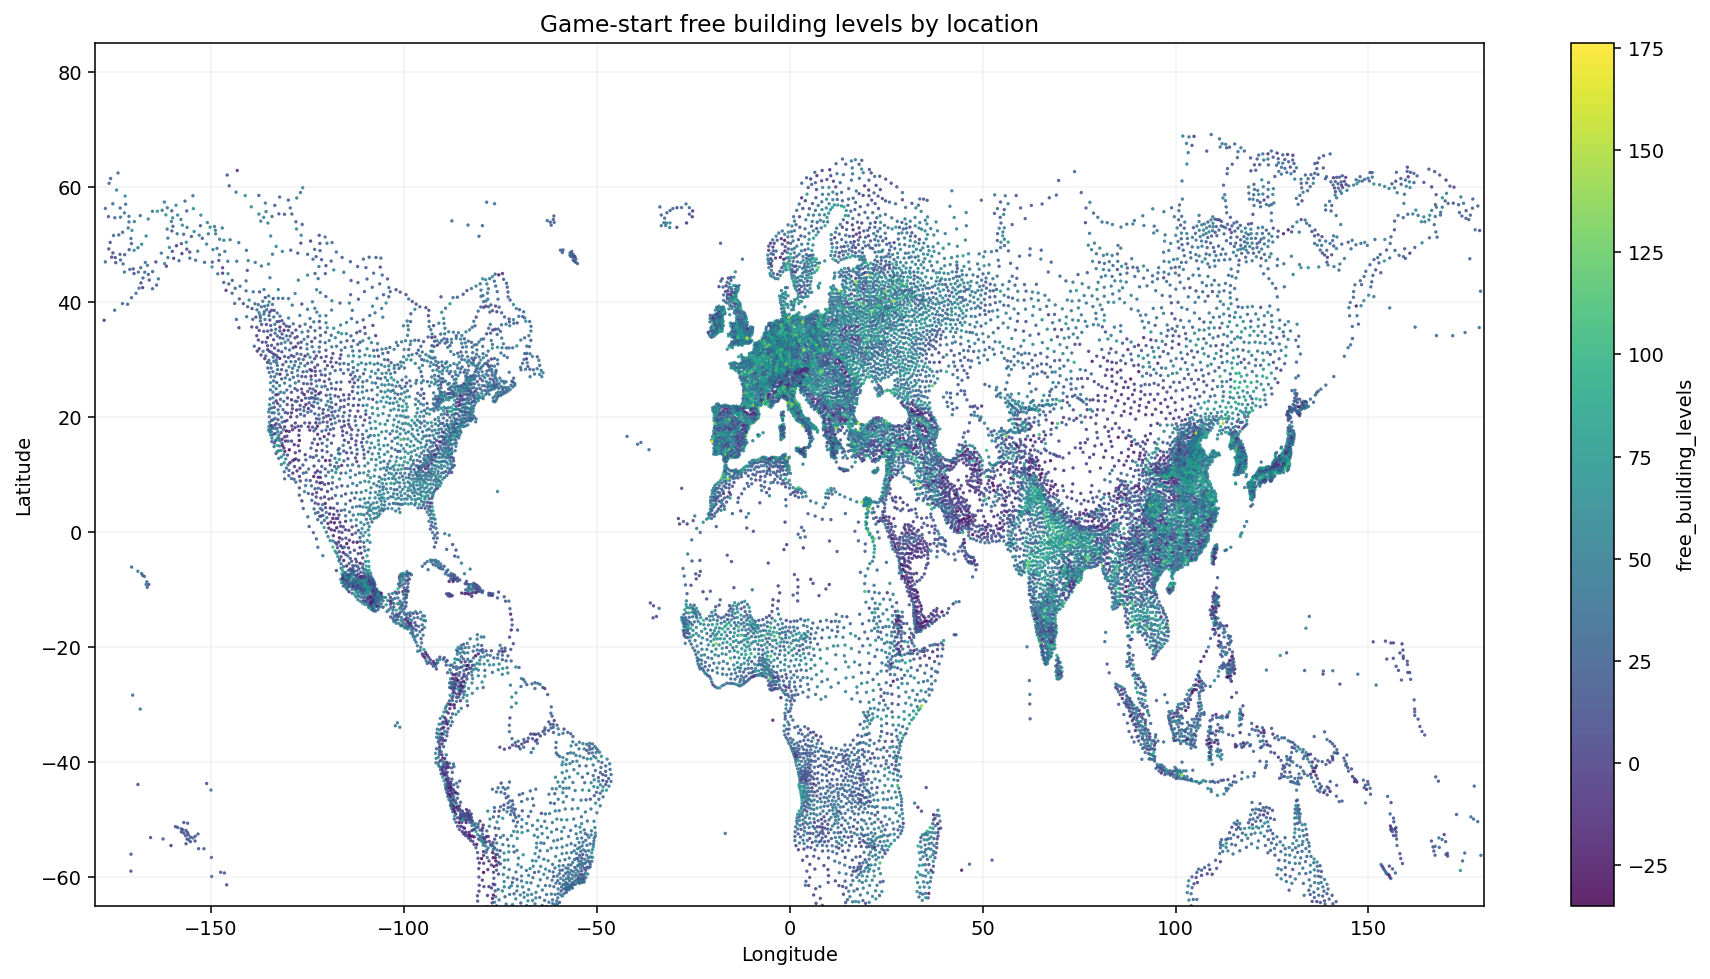

In [20]:
plot_location_world_map(
    plot_frame,
    "free_building_levels",
    title="Game-start free building levels by location",
    cmap="viridis",
)


## Building Efficiency World Map


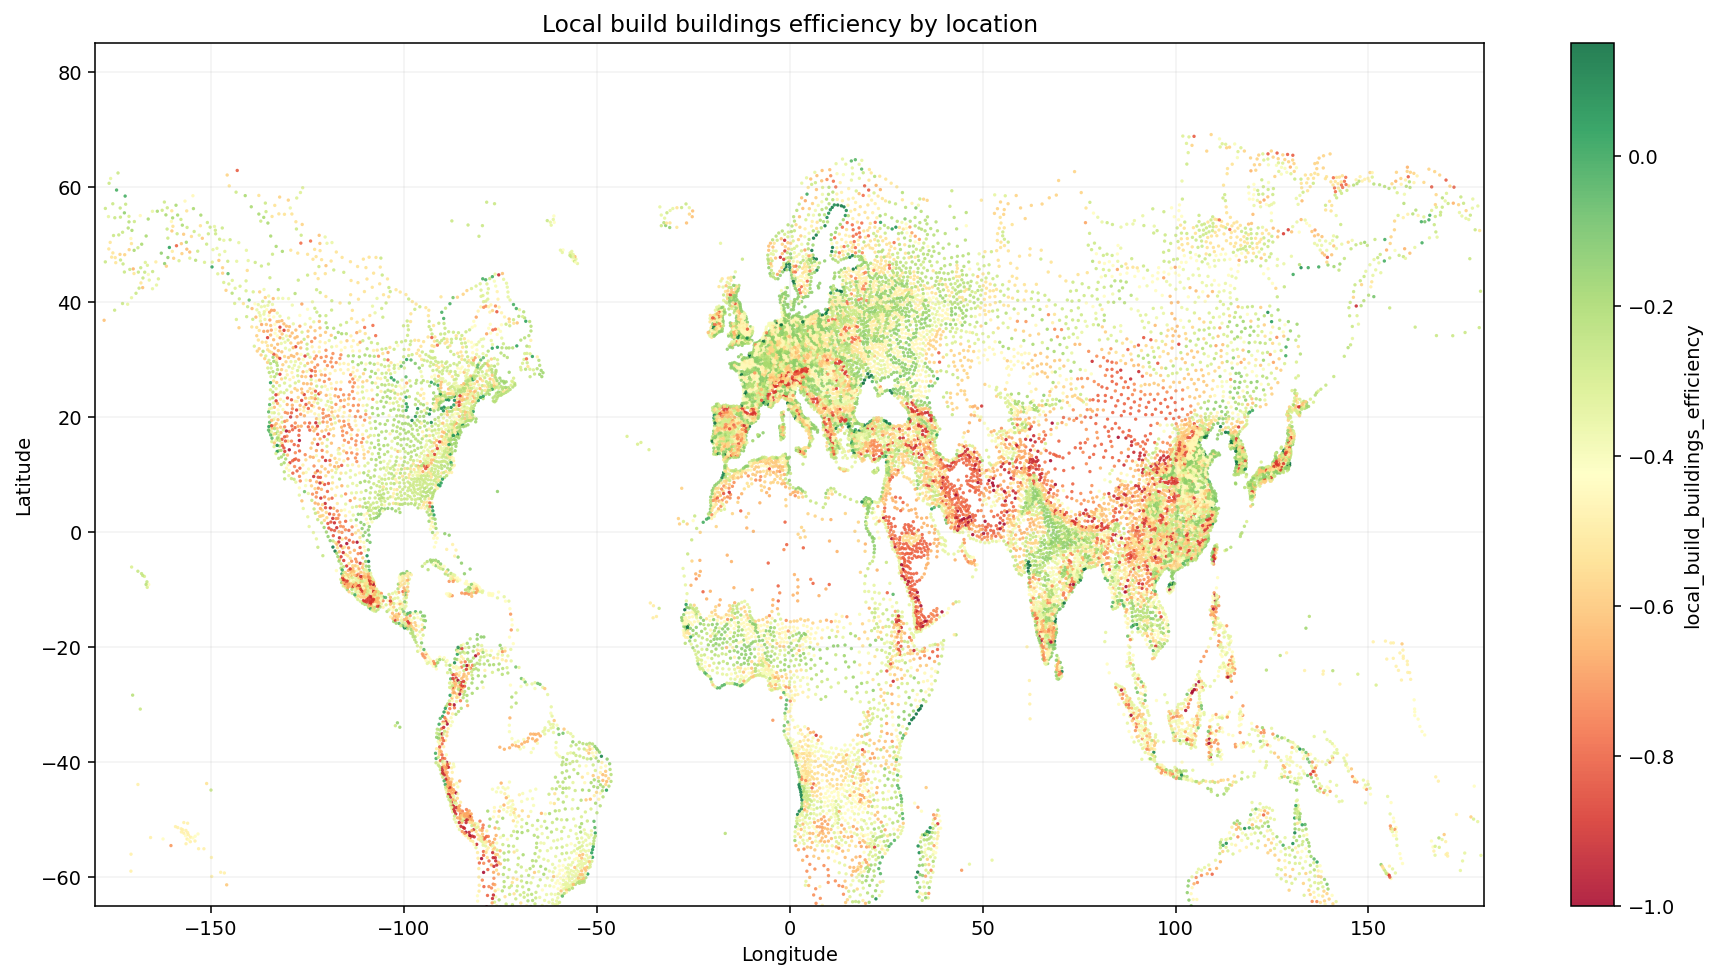

In [21]:
plot_location_world_map(
    plot_frame,
    LOCAL_BUILD_BUILDINGS_EFFICIENCY_COLUMN,
    title="Local build buildings efficiency by location",
    cmap="RdYlGn",
)


## Regional Aggregate Map


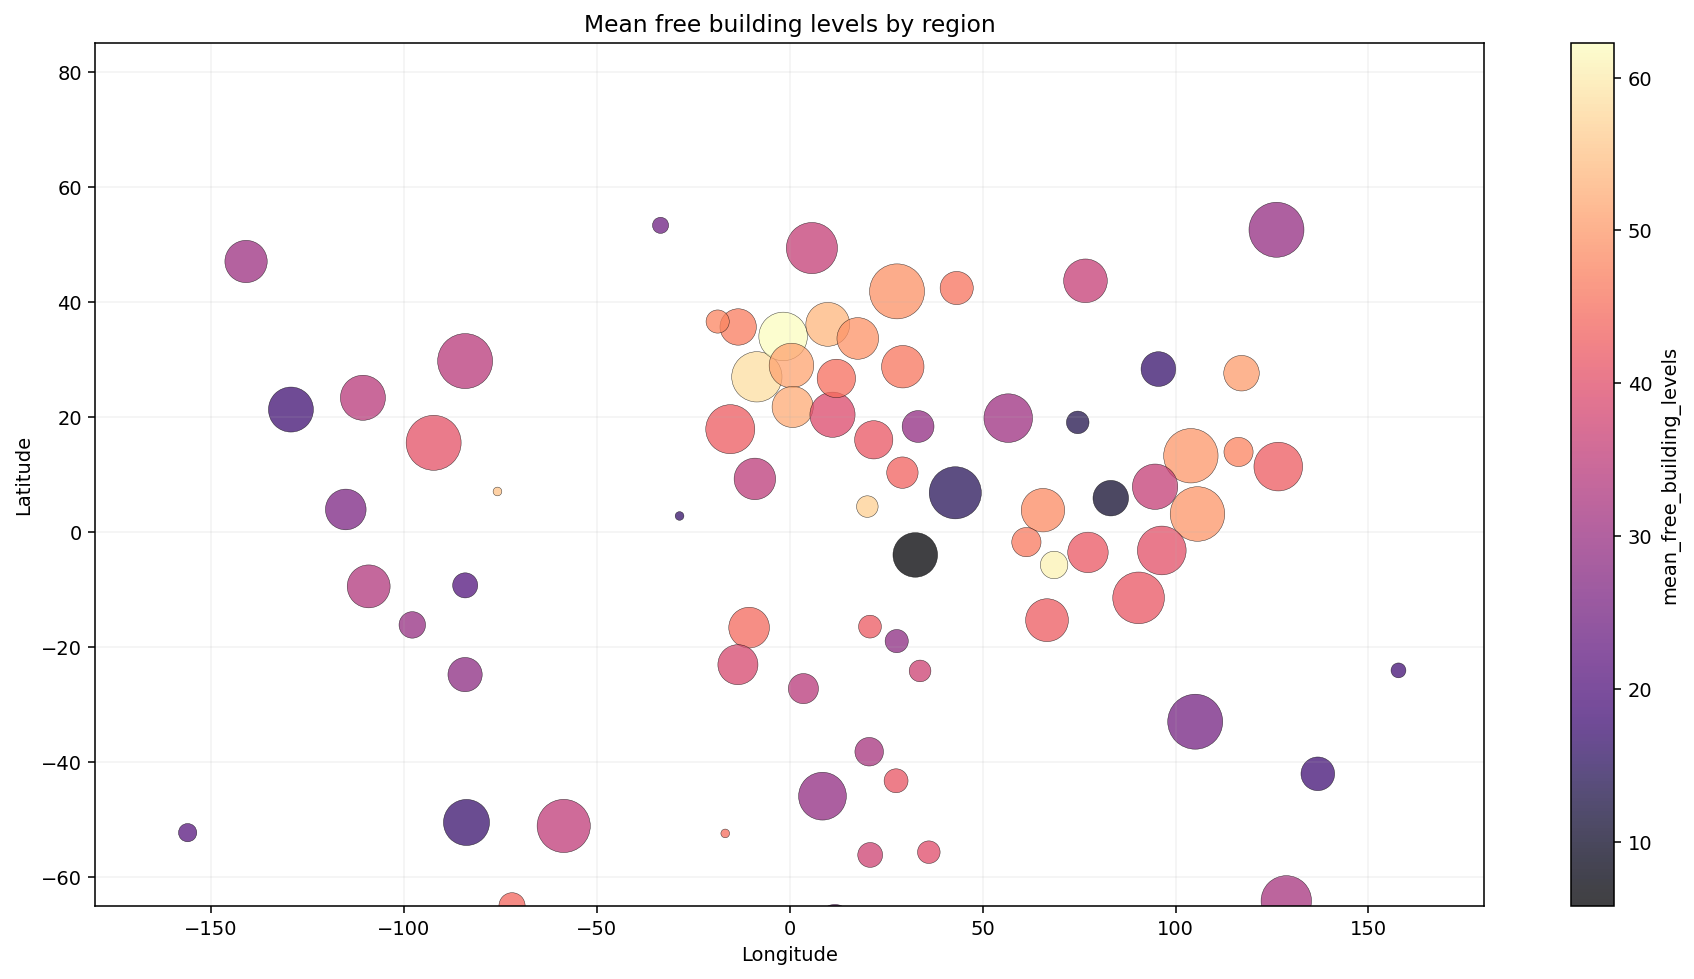

region,lon,lat,locations,mean_free_building_levels,total_free_building_levels
str,f64,f64,u32,f64,f64
"""russian_region""",27.80,41.84,560,49.18,27538.38
"""france_region""",-8.54,26.97,446,58.48,26083.50
"""north_china_region""",103.97,13.25,522,49.88,26036.12
"""east_china_region""",105.68,3.11,525,49.48,25979.62
"""north_german_region""",-1.72,34.00,416,62.25,25894.88
"""east_coast_region""",-92.32,15.50,628,40.81,25628.12
"""indochina_region""",90.42,-11.47,471,41.63,19608.62
"""canada_region""",-84.15,29.71,573,34.17,19579.00
"""baltic_region""",9.85,36.10,340,53.48,18184.00


In [22]:
region_plot = (
    plot_frame.group_by("region")
    .agg(
        pl.col("approx_lon").median().alias("lon"),
        pl.col("approx_lat").median().alias("lat"),
        pl.len().alias("locations"),
        pl.col("free_building_levels").mean().alias("mean_free_building_levels"),
        pl.col("free_building_levels").sum().alias("total_free_building_levels"),
    )
    .sort("total_free_building_levels", descending=True)
)
region_data = region_plot.to_dict(as_series=False)
region_vmin, region_vmax = color_limits(region_plot["mean_free_building_levels"])

plt.close("all")
fig, ax = plt.subplots(figsize=(16, 8), dpi=140)
sizes = [max(20, min(800, value * 1.5)) for value in region_data["locations"]]
scatter = ax.scatter(
    region_data["lon"],
    region_data["lat"],
    c=region_data["mean_free_building_levels"],
    s=sizes,
    cmap="magma",
    vmin=region_vmin,
    vmax=region_vmax,
    edgecolors="black",
    linewidths=0.25,
    alpha=0.75,
)
ax.set_xlim(-180, 180)
ax.set_ylim(-65, 85)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Mean free building levels by region")
fig.colorbar(scatter, ax=ax, label="mean_free_building_levels")
ax.grid(alpha=0.15)
plt.show()

display(round_numeric_columns(region_plot.head(30)))
